In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from faker import Faker

### Create a dataset of at least 300 course enrollments with:


- student_id, course_name, progress_percent, completion_days, rating


In [2]:
fake = Faker()

Faker.seed(42)
random.seed(42)
np.random.seed(42)

courses = [
    "Data Science", "Machine Learning", "Web Development",
    "Python Programming", "Deep Learning", "Cloud Computing"
]

data = []

for _ in range(300):
    student_id = fake.uuid4()
    course_name = random.choice(courses)

    r = random.random()

    if r < 0.35:
        progress_percent = 100
    elif r < 0.85:
        progress_percent = random.randint(40, 90)
    else:
        progress_percent = random.randint(0, 30)


    if progress_percent == 100:
        completion_days = random.randint(20,60)
    else:
        completion_days = random.randint(1, 20)

    rating = round(random.uniform(1, 5), 1)

    data.append({
        "student_id": student_id,
        "course_name": course_name,
        "progress_percent": progress_percent,
        "completion_days": completion_days,
        "rating": rating,
    })

df = pd.DataFrame(data)

In [3]:
df.head()

,student_id,course_name,progress_percent,completion_days,rating
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Cloud Computing,100,37,2.0
1,23b8c1e9-3924-46de-beb1-3b9046685257,Machine Learning,83,18,1.3
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Python Programming,100,25,1.9
3,972a8469-1641-4f82-8b9d-2434e465e150,Deep Learning,75,7,3.9
4,17fc695a-07a0-4a6e-8822-e8f36c031199,Cloud Computing,54,15,3.4


Using Pandas:


- Identify courses with poor completion performance.


- Compute average completion time per course.

In [4]:
completion_performance = df.groupby('course_name').agg(
    total_students = ('student_id', 'count'),
    completed_students = ('progress_percent', lambda x:(x == 100).sum()),
)

completion_performance['completion_rate'] = (completion_performance['completed_students'] / completion_performance['total_students']) * 100

completion_performance

,total_students,completed_students,completion_rate
course_name,,,
Cloud Computing,56,13,23.214286
Data Science,41,17,41.463415
Deep Learning,45,12,26.666667
Machine Learning,56,18,32.142857
Python Programming,53,18,33.962264
Web Development,49,16,32.653061


In [5]:
poor_completion_performance = completion_performance[ completion_performance['completion_rate'] < 30]

poor_completion_performance

,total_students,completed_students,completion_rate
course_name,,,
Cloud Computing,56,13,23.214286
Deep Learning,45,12,26.666667


In [6]:
average_completion_time = (df.groupby(['course_name'])['completion_days']
    .mean()
    .reset_index()
    .rename(columns={"completion_days": "average_completion_time"})
)

average_completion_time

,course_name,average_completion_time
0,Cloud Computing,15.875000
1,Data Science,25.195122
2,Deep Learning,16.155556
3,Machine Learning,19.035714
4,Python Programming,19.849057
5,Web Development,20.653061


Using NumPy:


- Perform statistical analysis on completion duration.


- Simulate improved progress scenarios.


In [7]:
data = df['completion_days'].values

print(f"mean: {np.mean(data):.2f}")
print(f"median: {np.median(data):.2f}")
print(f"Std Dev: {np.std(data):.2f}")
print(f"Min: {np.min(data):.2f}")
print(f"Max: {np.max(data):.2f}")

mean: 19.26
median: 15.00
Std Dev: 15.49
Min: 1.00
Max: 60.00


In [10]:
improved_progress = df['progress_percent'].values + np.random.randint(5, 20, size=len(df))

improved_progress = np.clip(improved_progress, 0, 100)

print(f"Average Average Time: {improved_progress.mean().round(2)}")

Average Average Time: 75.74


Using a visualization library:


- Visualize completion time distribution.


- Compare average ratings across courses.


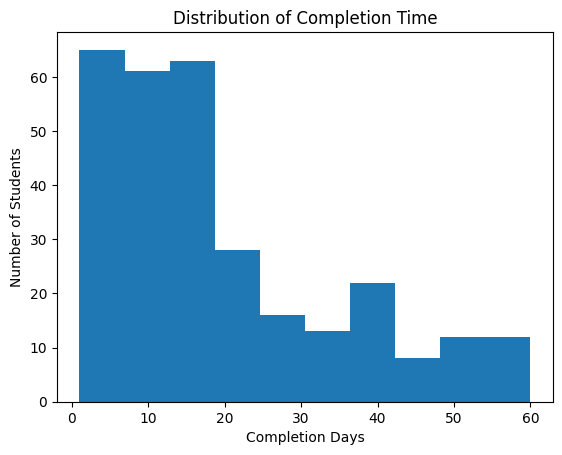

In [14]:
days = df['completion_days']

plt.figure()
plt.hist(days, bins=10)

plt.xlabel("Completion Days")
plt.ylabel("Number of Students")
plt.title("Distribution of Completion Time")

plt.show()

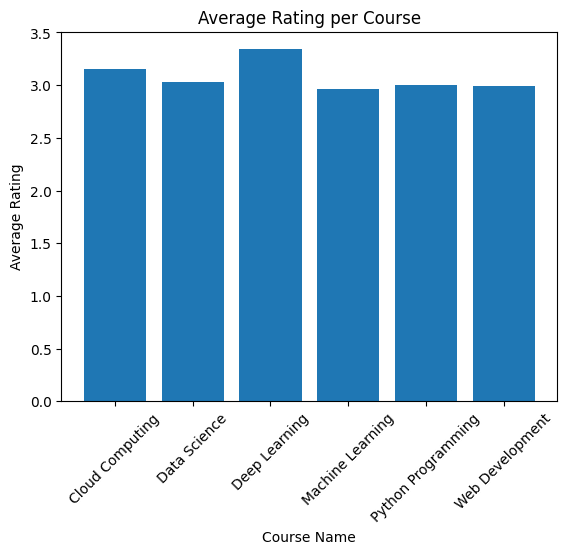

In [15]:
avg_rating = df.groupby('course_name')['rating'].mean()
avg_rating = avg_rating.reset_index()
avg_rating.rename(columns={'rating': 'avg_rating'}, inplace=True)


plt.figure()
plt.bar(avg_rating['course_name'], avg_rating['avg_rating'])

plt.xlabel("Course Name")
plt.ylabel("Average Rating")
plt.title("Average Rating per Course")

plt.xticks(rotation=45)
plt.show()